In [1]:
%load_ext autoreload
%autoreload 2

import numpy  as np
import pandas as pd
import h5py
from pathlib import Path

from astropy    import units as u
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
# matplotlib.use('Agg')

# font = {'family' : 'normal',
#         'size'   : 8}

# matplotlib.rc('font', **font)


from scipy.interpolate import RegularGridInterpolator
from scipy.signal      import argrelextrema

from common import hallmark as hm
from common import mockservation as mk
from common import io_raptor as io
from common import dalt
from common import viz

import plotscripts
from plotscripts import subtract, image2d, loadfigure, getimagedata

import rapplot

from module import *

In [2]:
#Computing relevant constants
M=4.14e6  * rapplot.MSUN
d= 8.127* rapplot.KPC

rg = (rapplot.G*M/rapplot.SPEED_OF_LIGHT**2.)

mas = (rg/d)* rapplot.MAS_IN_DEG

Tunit =rg/rapplot.SPEED_OF_LIGHT

halfrange=20 #in rg

## Plot High Res image

In [ ]:
plt.figure(figsize=(30,30),facecolor='w')
fig, ax = plt.subplots(1,1,figsize=(5,4), sharex=True, sharey=True)
img_path = "cache/Ma101_w1/Rh1_i60"

# get image
data_id_all, min, max, image_array = subtract(img_path+"/n100", img_path+"/n0", 999 , ave=False)
# data_id_all, min, max, image_array = getimagedata(img_path+'/n100', 999)


#get critical curve 
alpha1, beta1 = import_ab(1.01, 60, True) 
# connect edge
alpha_closed = np.r_[alpha1[0:200000], alpha1[1]]
beta_closed =  np.r_[beta1[0:200000], beta1[1]] 

# plot original arc 
ax.plot(alpha1, beta1, linewidth=1, color='deepskyblue', linestyle='-')
# plot connecting line 
ax.plot(alpha_closed, beta_closed, linewidth=1, color='deepskyblue', linestyle='--')

# inner, outter = extractimg_inout(image_array, alpha1, beta1)

figure = loadfigure(image_array, np.min(image_array), np.max(image_array), fig, ax, 20, 1, label="Stokes", cmap="afmhot")

ax.set_xlabel(r"x [mas]")
ax.set_ylabel(r"y [mas]")
ax.set_xlim(-8, 8)
ax.set_ylim(-8, 8)

fig.colorbar(figure, ax=ax)
fig.savefig(f"output/plot/HPR_avei60.jpg", dpi=1000)
# fig.savefig(f"HPR.pdf")

read from cache/Ma101_w1/Rh1_i60/n100 and cache/Ma101_w1/Rh1_i60/n0
Reading in:  cache/Ma101_w1/Rh1_i60/n100/img_data_999.h5
8
Reading in:  cache/Ma101_w1/Rh1_i60/n0/img_data_999.h5
8
Reading in:  cache/Ma101_w1/Rh1_i60/n100/img_data_1000.h5
8


## Higher order photon rings structures

In [3]:
# Load all images 
pf = hm.ParaFrame('cache/{mag}a{aspin:g}_w{window:d}/Rh{Rhigh:d}_i{inc:d}/n{n:n}/img_data_{snapshot:d}.h5')
sel = pf(snapshot=[999, 1000, 101000])
display(sel)

,path,mag,aspin,window,Rhigh,inc,n,snapshot
1,cache/Ma101_w1/Rh1_i15/n0/img_data_999.h5,M,101.0,1,1,15,0,999
2,cache/Ma101_w1/Rh1_i15/n1/img_data_1000.h5,M,101.0,1,1,15,1,1000
3,cache/Ma101_w1/Rh1_i15/n1/img_data_101000.h5,M,101.0,1,1,15,1,101000
6,cache/Ma101_w1/Rh1_i15/n1/img_data_999.h5,M,101.0,1,1,15,1,999
8,cache/Ma101_w1/Rh1_i15/n100/img_data_999.h5,M,101.0,1,1,15,100,999
9,cache/Ma101_w1/Rh1_i15/n2/img_data_1000.h5,M,101.0,1,1,15,2,1000
10,cache/Ma101_w1/Rh1_i15/n2/img_data_101000.h5,M,101.0,1,1,15,2,101000
13,cache/Ma101_w1/Rh1_i15/n2/img_data_999.h5,M,101.0,1,1,15,2,999
16,cache/Ma101_w1/Rh1_i30/n0/img_data_999.h5,M,101.0,1,1,30,0,999
17,cache/Ma101_w1/Rh1_i30/n1/img_data_1000.h5,M,101.0,1,1,30,1,1000


In [4]:
ns = np.sort( np.array(sel.n.unique()))
incs = np.sort(np.array(sel.inc.unique())) 

print("n: ", ns)
print("inc: ", incs[0:len(incs)])

n:  [  0   1   2 100]
inc:  [15 30 45 60 75]


In [5]:
# substruct 
# for n in [1,2]: 
#     for inc in incs: 

#         try:
#             s_0 = sel[(sel['inc']==inc) & (sel['n']==n ) & (sel['snapshot']==999)]
#             s_1 = sel[(sel['inc']==inc) & (sel['n']==(n-1)) & (sel['snapshot']==999) ]

#             path_object_0 = Path(s_0.path.item())
#             img_path_0 = str( path_object_0.parent )
#             path_object_1 = Path(s_1.path.item())
#             img_path_1 = str( path_object_1.parent )

#             subtract(img_path_0, img_path_1, 999 , ave=False)

#         except: 
#             print("Error: ", inc, n)


In [6]:
# fig, axes = plt.subplots(len(incs), len(ns) + 1, figsize=(len(ns) + 1, len(incs)), sharex=True, sharey=True)

# for row, inc in enumerate(incs):  # row = inclination
#     imgs_list = []
#     for col, n in enumerate(ns):  # col = photon ring order
#         ax = axes[row, col]

#         if n in [1, 2]:
            
#             # s = sel[(sel['inc'] == inc) & (sel['n'] == n) & (sel['snapshot'] == 1000)]
#             # snapshot = 1000
        
#             s = sel[(sel['inc'] == inc) & (sel['n'] == n) & (sel['snapshot'] == 101000)]
#             snapshot = 101000
#         else:
#             s = sel[(sel['inc'] == inc) & (sel['n'] == n) & (sel['snapshot'] == 999)]
#             snapshot = 999

#         if s.path.shape == (1,):
#             path_object = Path(s.path.item())
#             img_path = str(path_object.parent)
#             if snapshot==101000:
#                 data_id_all, min, max, image_array = getimagedata(img_path, snapshot, resize=False)
#             else: 
#                 data_id_all, min, max, image_array = getimagedata(img_path, snapshot, resize=True)
                
#             figure = loadfigure(image_array, min, max, fig, ax, halfrange=halfrange, mas=mas, label="Stokes", cmap="afmhot")
#             ax.set_xlim(-0.05, 0.05)
#             ax.set_ylim(-0.05, 0.05)
#             ax.set_aspect('equal')
#         else:
#             print("error", inc, n)
#             continue

#         if n in [0, 1, 2]:
#             imgs_list.append(image_array)

#         if row == 0:
#             if n == 100:
#                 ax.set_title("Total", fontsize=10)
#             else:
#                 ax.set_title(f"n = {n}", fontsize=10)

#     axes[row, 0].set_ylabel(f"i = {inc}", fontsize=10, rotation=0, labelpad=20, va='center')

#     imgs = np.stack(imgs_list, axis=0)
#     legend_handles = plotregion(imgs, axes[row, -1])
#     axes[row, -1].set_aspect('equal')

# # Global legend
# fig.legend(handles=legend_handles, bbox_to_anchor=(1.1, 0.9), frameon=False)

# # Add colorbar
# cbar_ax = fig.add_axes([0.9, 0.1, 0.02, 0.6])
# fig.colorbar(figure, cax=cbar_ax, orientation='vertical')

# #
# fig.subplots_adjust(left=0, right=0.85, top=0.9, bottom=0.1, wspace=0.3, hspace=0.3)

# # Save
# fig.savefig("output/table/hpr.jpg", bbox_inches='tight', dpi=300)
# # plt.close(fig)
# print('DONE:')

## VAs per angle

DONE: 15
DONE: 30
DONE: 45
DONE: 60
DONE: 75


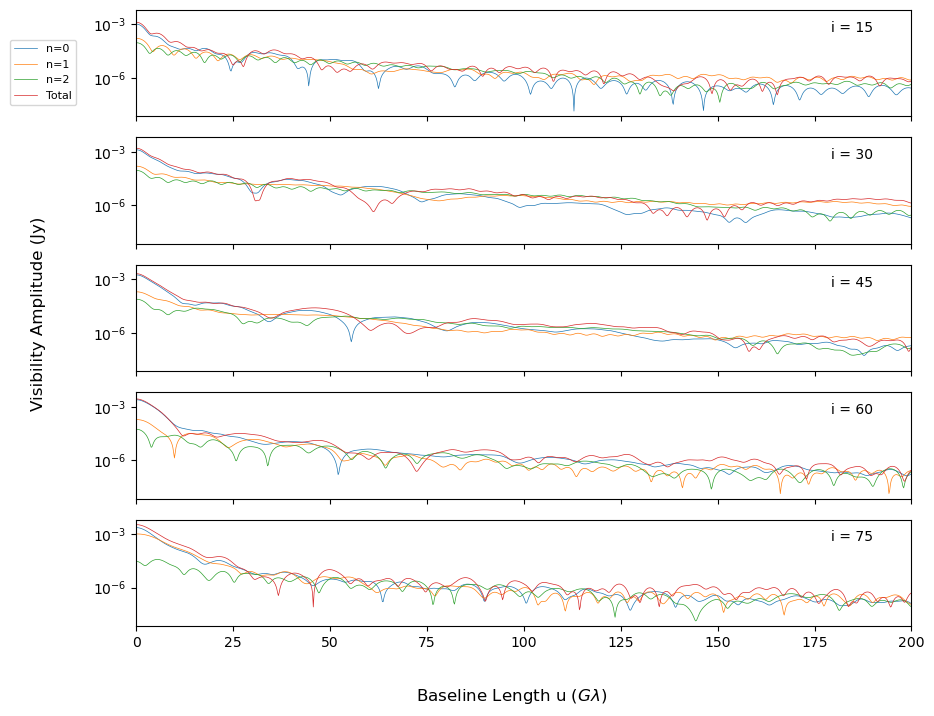

In [5]:
fig, axes = plt.subplots(5, 1, figsize=(10, 8), sharey=True, sharex=True)


legend_handles = []  

for row, inc in enumerate(incs[0:len(incs)]):
    ax = axes[row]
    
    for col, n in enumerate(ns): 
        if n in [1, 2]: 
            # if inc!=45:
            s = sel[(sel['inc'] == inc) & (sel['n'] == n) & (sel['snapshot'] == 1000)]
        else: 
            s = sel[(sel['inc'] == inc) & (sel['n'] == n) & (sel['snapshot'] == 999)]
        
        path_object = Path(s.path.item())
        mov = io.load_mov(s.path, [1000 if n in [1, 2] else 999])
        
        # Plot VA

        handles = plot_va(mov, ax, n, inc )
        if handles:
            legend_handles.extend(handles)

            
    ax.text(0.95, 0.9, f"i = {inc}", transform=ax.transAxes,
            fontsize=10, ha='right', va='top')
    ax.set_xlim(0,200)
    print("DONE:", inc)

fig.legend(handles=legend_handles[0:4],
           fontsize=8,
           bbox_to_anchor=(0.07, 0.85),
           frameon=True)

# fig.tight_layout(pad=0, w_pad=0, h_pad=0)
fig.supxlabel(r"Baseline Length u ($G\lambda$)")
fig.supylabel("Visibility Amplitude (Jy)")   
fig.savefig("output/table/va.pdf", bbox_inches='tight')
